# LG+C10 Profile Mixture Model — Backend Comparison (AA)
## IQ-TREE 3: OMP_10 vs OMP_48 vs OPENACC vs VANILA

Results from: `/Users/u7826985/Projects/Nvidia/results/2026_04_19_profile_mixture_comparison/AA/`

Alignment lengths tested: 100, 1 000, 10 000, 100 000, 1 000 000 sites  
Sequences: 100 taxa | Model: LG+C10+G4

In [30]:
import re
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RESULTS_DIR = Path("/Users/u7826985/Projects/Nvidia/results/2026_04_19_profile_mixture_comparison/AA")
OUT_DIR = Path(".")

BACKEND_ORDER  = ["VANILA", "OMP_10", "OMP_48", "OPENACC"]
BACKEND_LABELS = {"VANILA": "VANILA (baseline)", "OMP_10": "OMP 10T", "OMP_48": "OMP 48T", "OPENACC": "OpenACC (GPU)"}
BACKEND_COLORS = {"VANILA": "#6c757d", "OMP_10": "#0077b6", "OMP_48": "#00b4d8", "OPENACC": "#d62728"}
BACKEND_MARKERS= {"VANILA": "s", "OMP_10": "o", "OMP_48": "^", "OPENACC": "D"}

print("Imports OK — results dir exists:", RESULTS_DIR.exists())

Imports OK — results dir exists: True


In [31]:
## Parse log files
from typing import Optional

def detect_backend(fname):
    for b in ["OMP_10", "OMP_48", "OPENACC", "VANILA"]:
        if b in fname:
            return b
    return "UNKNOWN"

def parse_log(path: Path) -> Optional[dict]:
    try:
        text = path.read_text(errors="replace")
    except Exception:
        return None

    def find_float(pattern, default=None):
        m = re.search(pattern, text)
        return float(m.group(1)) if m else default

    def find_int(pattern, default=None):
        m = re.search(pattern, text)
        return int(m.group(1)) if m else default

    # Timing — take last occurrence (final totals)
    wall_matches = re.findall(r"Total wall-clock time used:\s+([\d.]+)\s+sec", text)
    cpu_matches  = re.findall(r"Total CPU time used:\s+([\d.]+)\s+sec", text)
    wall_search_matches = re.findall(r"Wall-clock time used for tree search:\s+([\d.]+)\s+sec", text)
    cpu_search_matches  = re.findall(r"CPU time used for tree search:\s+([\d.]+)\s+sec", text)

    wall_total  = float(wall_matches[-1])  if wall_matches  else None
    cpu_total   = float(cpu_matches[-1])   if cpu_matches   else None
    wall_search = float(wall_search_matches[-1]) if wall_search_matches else None
    cpu_search  = float(cpu_search_matches[-1])  if cpu_search_matches  else None

    if wall_total is None:
        return None  # incomplete run

    backend = detect_backend(path.name)
    seq_len = int(path.parent.name.replace("len_", ""))

    # Thread count from kernel line
    threads = None
    km = re.search(r"Kernel\s*:\s*\S+\s*-\s*(\d+)\s+threads", text)
    if km:
        threads = int(km.group(1))

    # Model parameters
    logl       = find_float(r"BEST SCORE FOUND\s*:\s*(-[\d.]+)")
    gamma_alpha= find_float(r"Gamma shape alpha:\s*([\d.]+)")
    tree_len   = find_float(r"Total tree length.*?:\s*([\d.]+)")
    iterations = find_int(r"Total number of iterations:\s*(\d+)")

    # Mixture weights (last occurrence)
    mw_matches = re.findall(r"Mixture weights:\s*([\d. ]+)", text)
    mix_weights = None
    if mw_matches:
        w = [float(x) for x in mw_matches[-1].strip().split()]
        mix_weights = w if len(w) == 10 else None

    # Number of sequences and sites from alignment line
    am = re.search(r"Alignment has (\d+) sequences with (\d+)", text)
    n_seq  = int(am.group(1)) if am else None
    n_site = int(am.group(2)) if am else None

    return {
        "backend"     : backend,
        "seq_len"     : seq_len,
        "threads"     : threads,
        "n_seq"       : n_seq,
        "n_site"      : n_site,
        "wall_total"  : wall_total,
        "cpu_total"   : cpu_total,
        "wall_search" : wall_search,
        "cpu_search"  : cpu_search,
        "logl"        : logl,
        "gamma_alpha" : gamma_alpha,
        "tree_len"    : tree_len,
        "iterations"  : iterations,
        "mix_weights" : mix_weights,
        "log_file"    : str(path),
    }

records = []
for log_path in sorted(RESULTS_DIR.rglob("*.log")):
    rec = parse_log(log_path)
    if rec:
        records.append(rec)

df = pd.DataFrame(records)
df = df[df["backend"].isin(BACKEND_ORDER)].copy()
df["backend"] = pd.Categorical(df["backend"], categories=BACKEND_ORDER, ordered=True)
df = df.sort_values(["seq_len", "backend"]).reset_index(drop=True)

# Derived columns
df["wall_min"]    = df["wall_total"] / 60
df["cpu_min"]     = df["cpu_total"]  / 60
df["parallel_eff"]= df["cpu_total"]  / (df["wall_total"] * df["threads"].fillna(1))

print(f"Parsed {len(df)} complete runs")
df[["backend","seq_len","threads","wall_total","cpu_total","logl","gamma_alpha","tree_len","iterations"]]

Parsed 11 complete runs


,backend,seq_len,threads,wall_total,cpu_total,logl,gamma_alpha,tree_len,iterations
0,VANILA,100,1,1067.732,1061.594,-7944.893,0.839,25.762,102
1,OMP_10,100,10,210.116,2062.343,-7944.893,0.839,25.762,102
2,OMP_48,100,48,263.712,3097.145,-7944.893,0.839,25.762,102
3,OPENACC,100,1,701.792,701.645,-7944.893,0.839,25.762,102
4,VANILA,1000,1,7889.312,7842.974,-80578.840,0.927,24.923,102
5,OMP_10,1000,10,903.593,8929.773,-80578.840,0.927,24.923,102
6,OMP_48,1000,48,566.303,26293.792,-80578.840,0.927,24.923,102
7,OPENACC,1000,1,738.428,738.267,-80578.840,0.927,24.923,102
8,OMP_10,10000,10,8093.220,79791.394,-837336.220,0.926,26.498,102
9,OMP_48,10000,48,3127.999,147488.704,-837336.220,0.926,26.498,102


In [32]:
# Compute speedup relative to VANILA baseline
vanila = df[df["backend"] == "VANILA"][["seq_len", "wall_total"]].set_index("seq_len").rename(columns={"wall_total": "vanila_wall"})
df = df.join(vanila, on="seq_len")
df["speedup"] = df["vanila_wall"] / df["wall_total"]
print(df[["backend","seq_len","wall_total","speedup"]].to_string(index=False))

backend  seq_len  wall_total   speedup
 VANILA      100    1067.732  1.000000
 OMP_10      100     210.116  5.081631
 OMP_48      100     263.712  4.048856
OPENACC      100     701.792  1.521437
 VANILA     1000    7889.312  1.000000
 OMP_10     1000     903.593  8.731046
 OMP_48     1000     566.303 13.931256
OPENACC     1000     738.428 10.683929
 OMP_10    10000    8093.220       NaN
 OMP_48    10000    3127.999       NaN
OPENACC    10000    2265.907       NaN


## Figure 1 — Wall-clock time vs alignment length

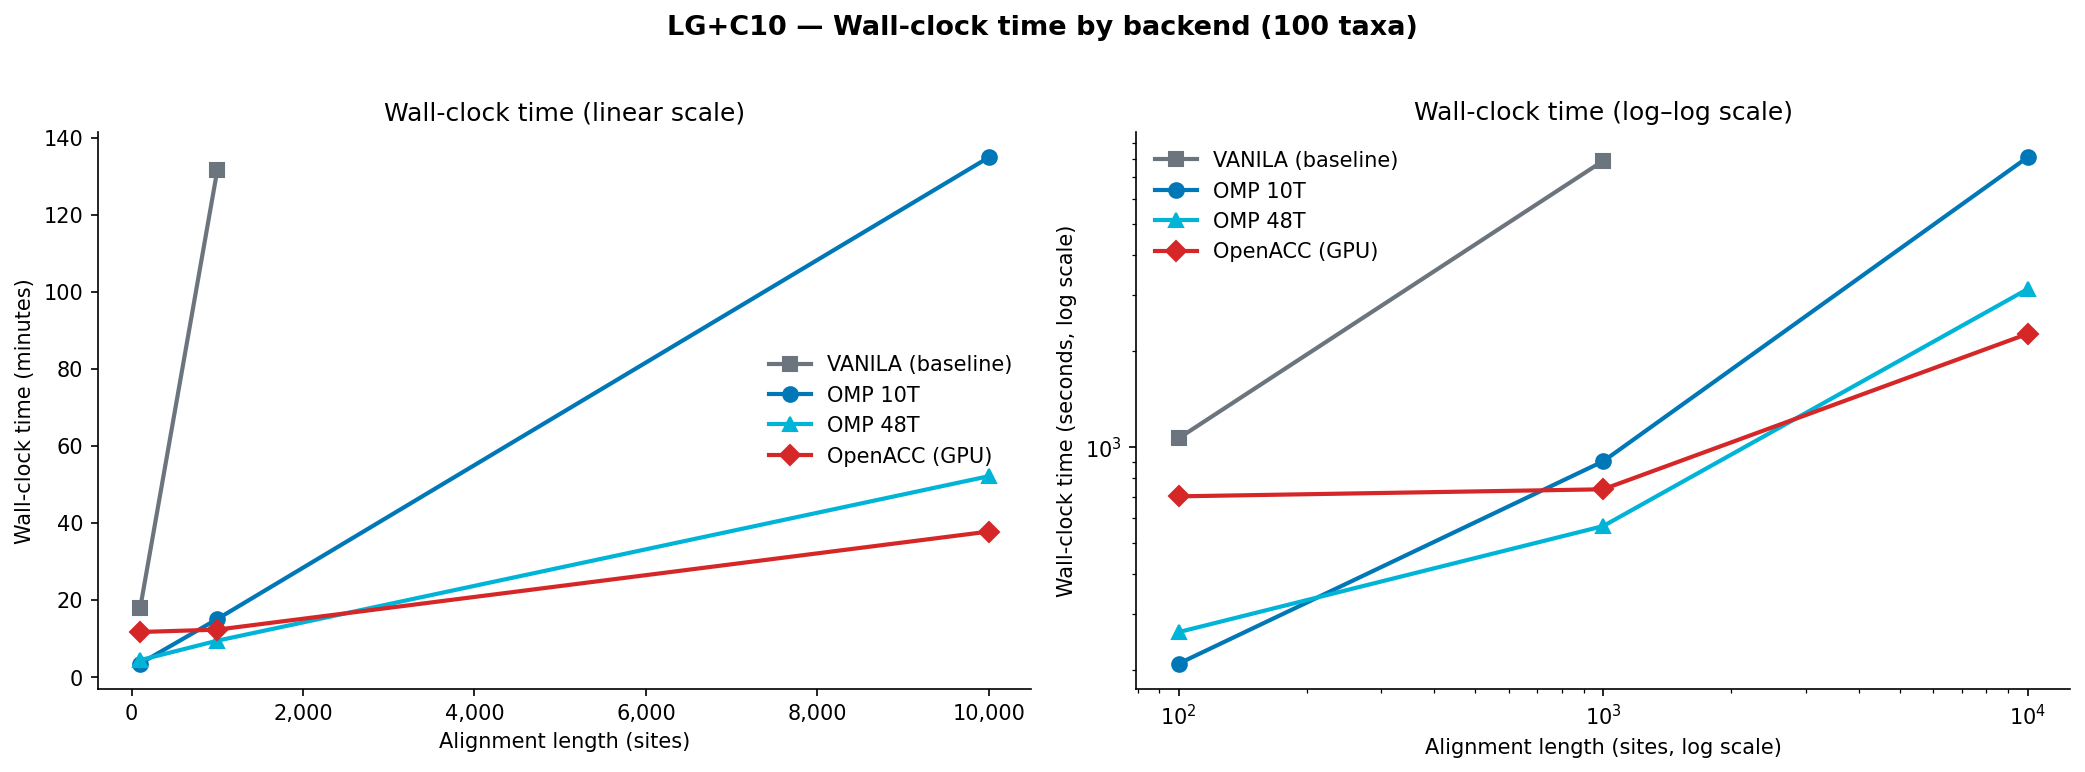

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lengths = sorted(df["seq_len"].unique())

# --- left: linear scale ---
ax = axes[0]
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].sort_values("seq_len")
    if sub.empty:
        continue
    ax.plot(sub["seq_len"], sub["wall_total"] / 60,
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=7, label=BACKEND_LABELS[b])
ax.set_xlabel("Alignment length (sites)")
ax.set_ylabel("Wall-clock time (minutes)")
ax.set_title("Wall-clock time (linear scale)")
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# --- right: log-log scale ---
ax = axes[1]
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].sort_values("seq_len")
    if sub.empty:
        continue
    ax.plot(sub["seq_len"], sub["wall_total"],
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=7, label=BACKEND_LABELS[b])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Alignment length (sites, log scale)")
ax.set_ylabel("Wall-clock time (seconds, log scale)")
ax.set_title("Wall-clock time (log–log scale)")
ax.legend(frameon=False)

plt.suptitle("LG+C10 — Wall-clock time by backend (100 taxa)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig1_wallclock_time.png", bbox_inches="tight")
plt.show()

## Figure 2 — Grouped bar chart: wall-clock time per length

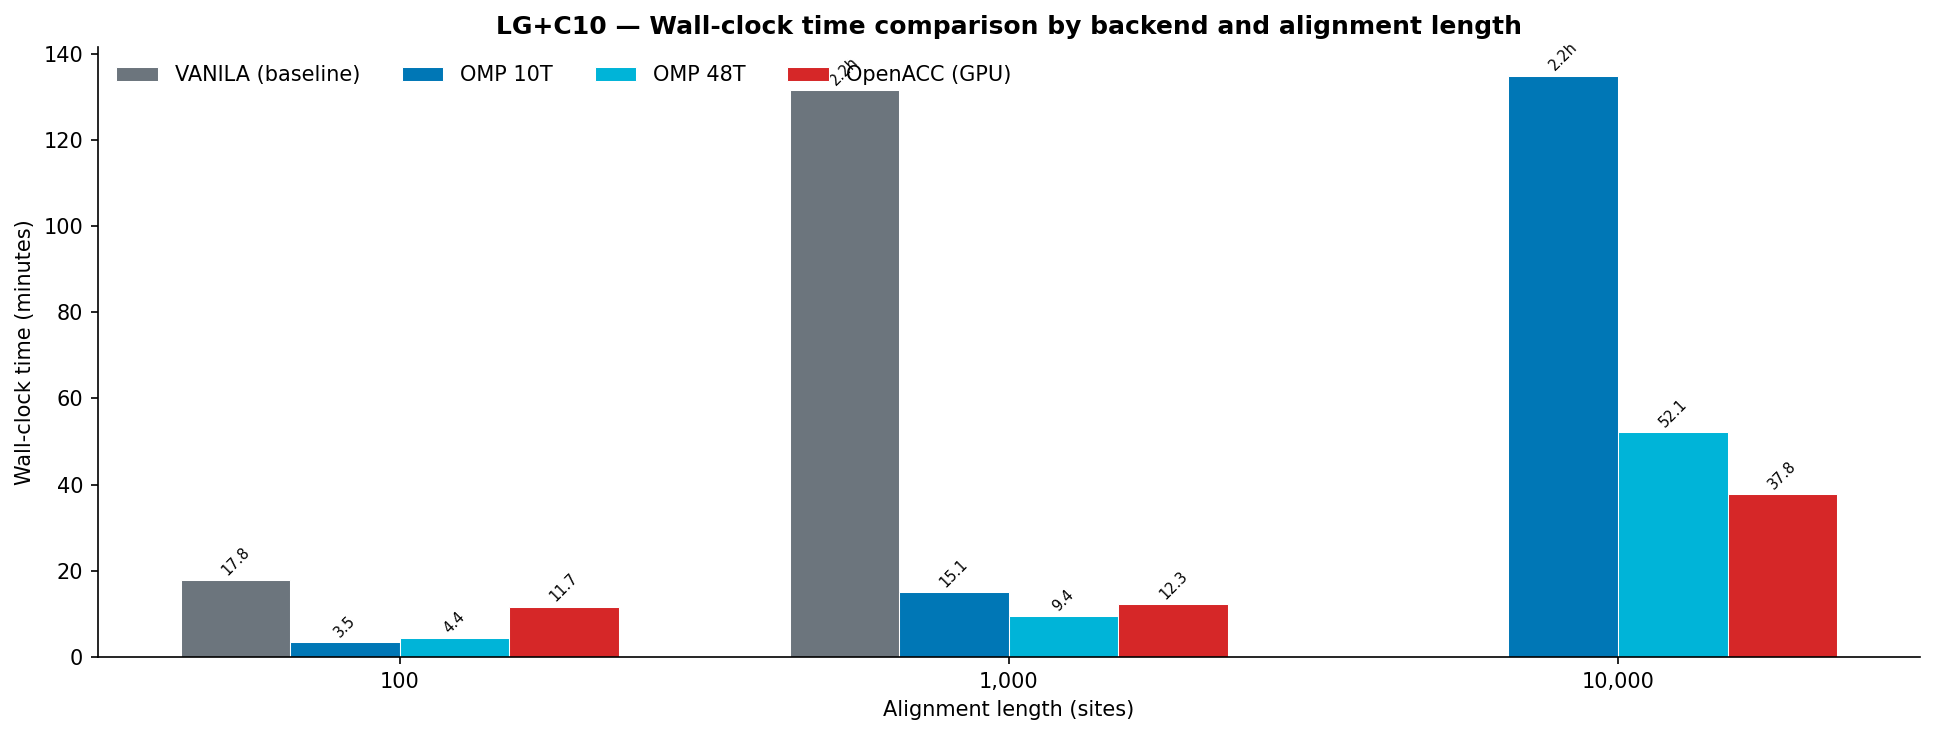

In [34]:
lengths = sorted(df["seq_len"].unique())
n_lengths  = len(lengths)
n_backends = len(BACKEND_ORDER)
bar_width   = 0.18
x = np.arange(n_lengths)

fig, ax = plt.subplots(figsize=(13, 5))

for i, b in enumerate(BACKEND_ORDER):
    sub = df[df["backend"] == b].sort_values("seq_len")
    vals = []
    for L in lengths:
        row = sub[sub["seq_len"] == L]
        vals.append(row["wall_total"].values[0] / 60 if not row.empty else np.nan)
    offset = (i - (n_backends - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals, bar_width,
                  label=BACKEND_LABELS[b], color=BACKEND_COLORS[b], edgecolor="white", lw=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            label = f"{v:.1f}" if v < 60 else f"{v/60:.1f}h"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    label, ha="center", va="bottom", fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels([f"{L:,}" for L in lengths])
ax.set_xlabel("Alignment length (sites)")
ax.set_ylabel("Wall-clock time (minutes)")
ax.set_title("LG+C10 — Wall-clock time comparison by backend and alignment length", fontweight="bold")
ax.legend(frameon=False, ncol=4)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig2_wallclock_bar.png", bbox_inches="tight")
plt.show()

## Figure 3 — Speedup over VANILA baseline

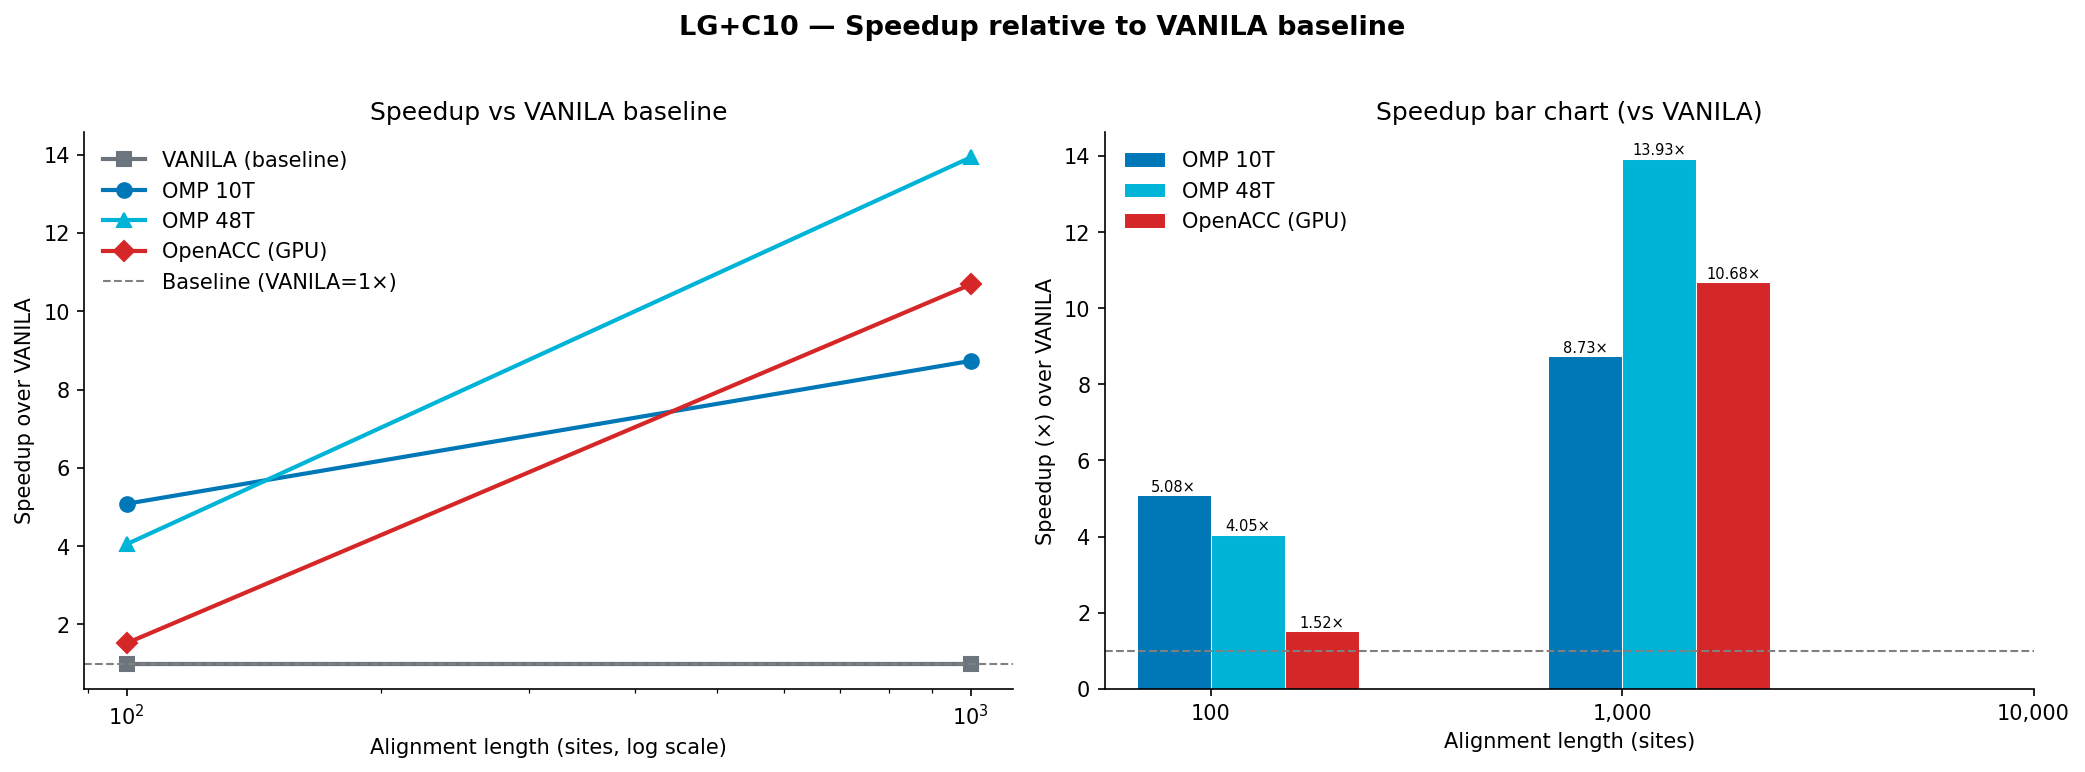

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: speedup line ---
ax = axes[0]
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].sort_values("seq_len")
    if sub.empty:
        continue
    ax.plot(sub["seq_len"], sub["speedup"],
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=7, label=BACKEND_LABELS[b])
ax.axhline(1, color="grey", lw=1, ls="--", label="Baseline (VANILA=1×)")
ax.set_xscale("log")
ax.set_xlabel("Alignment length (sites, log scale)")
ax.set_ylabel("Speedup over VANILA")
ax.set_title("Speedup vs VANILA baseline")
ax.legend(frameon=False)

# --- right: grouped bar ---
ax = axes[1]
x = np.arange(n_lengths)
for i, b in enumerate(BACKEND_ORDER):
    if b == "VANILA":
        continue
    sub = df[df["backend"] == b].sort_values("seq_len")
    vals = []
    for L in lengths:
        row = sub[sub["seq_len"] == L]
        vals.append(row["speedup"].values[0] if not row.empty else np.nan)
    offset = (i - (n_backends - 1) / 2) * bar_width
    bars = ax.bar(x + offset, vals, bar_width,
                  label=BACKEND_LABELS[b], color=BACKEND_COLORS[b], edgecolor="white", lw=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f"{v:.2f}×", ha="center", va="bottom", fontsize=7)

ax.axhline(1, color="grey", lw=1, ls="--")
ax.set_xticks(x)
ax.set_xticklabels([f"{L:,}" for L in lengths])
ax.set_xlabel("Alignment length (sites)")
ax.set_ylabel("Speedup (×) over VANILA")
ax.set_title("Speedup bar chart (vs VANILA)")
ax.legend(frameon=False)

plt.suptitle("LG+C10 — Speedup relative to VANILA baseline", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig3_speedup.png", bbox_inches="tight")
plt.show()

## Figure 4 — CPU time and parallelisation efficiency

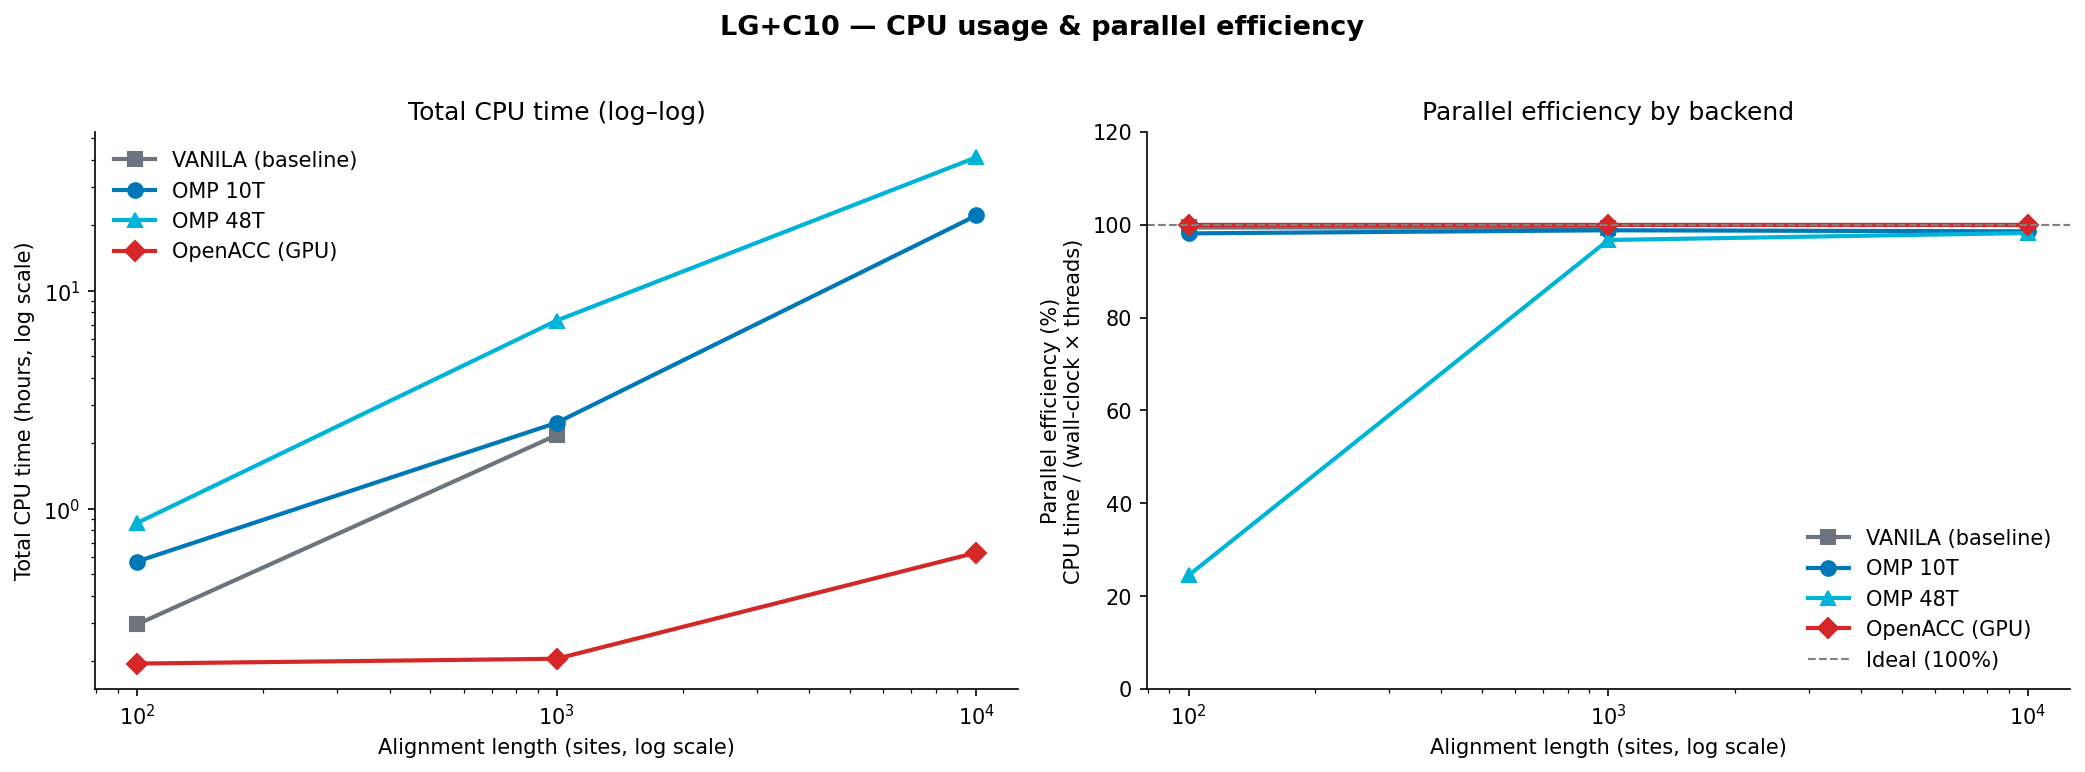

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: CPU time ---
ax = axes[0]
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].sort_values("seq_len")
    if sub.empty:
        continue
    ax.plot(sub["seq_len"], sub["cpu_total"] / 3600,
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=7, label=BACKEND_LABELS[b])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Alignment length (sites, log scale)")
ax.set_ylabel("Total CPU time (hours, log scale)")
ax.set_title("Total CPU time (log–log)")
ax.legend(frameon=False)

# --- right: parallel efficiency (CPU time / wall-clock / threads) ---
ax = axes[1]
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].dropna(subset=["parallel_eff"]).sort_values("seq_len")
    if sub.empty:
        continue
    ax.plot(sub["seq_len"], sub["parallel_eff"] * 100,
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=7, label=BACKEND_LABELS[b])
ax.axhline(100, color="grey", lw=1, ls="--", label="Ideal (100%)")
ax.set_xscale("log")
ax.set_ylim(0, 120)
ax.set_xlabel("Alignment length (sites, log scale)")
ax.set_ylabel("Parallel efficiency (%)\nCPU time / (wall-clock × threads)")
ax.set_title("Parallel efficiency by backend")
ax.legend(frameon=False)

plt.suptitle("LG+C10 — CPU usage & parallel efficiency", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig4_cpu_efficiency.png", bbox_inches="tight")
plt.show()

## Figure 5 — Model quality: log-likelihood and gamma shape alpha

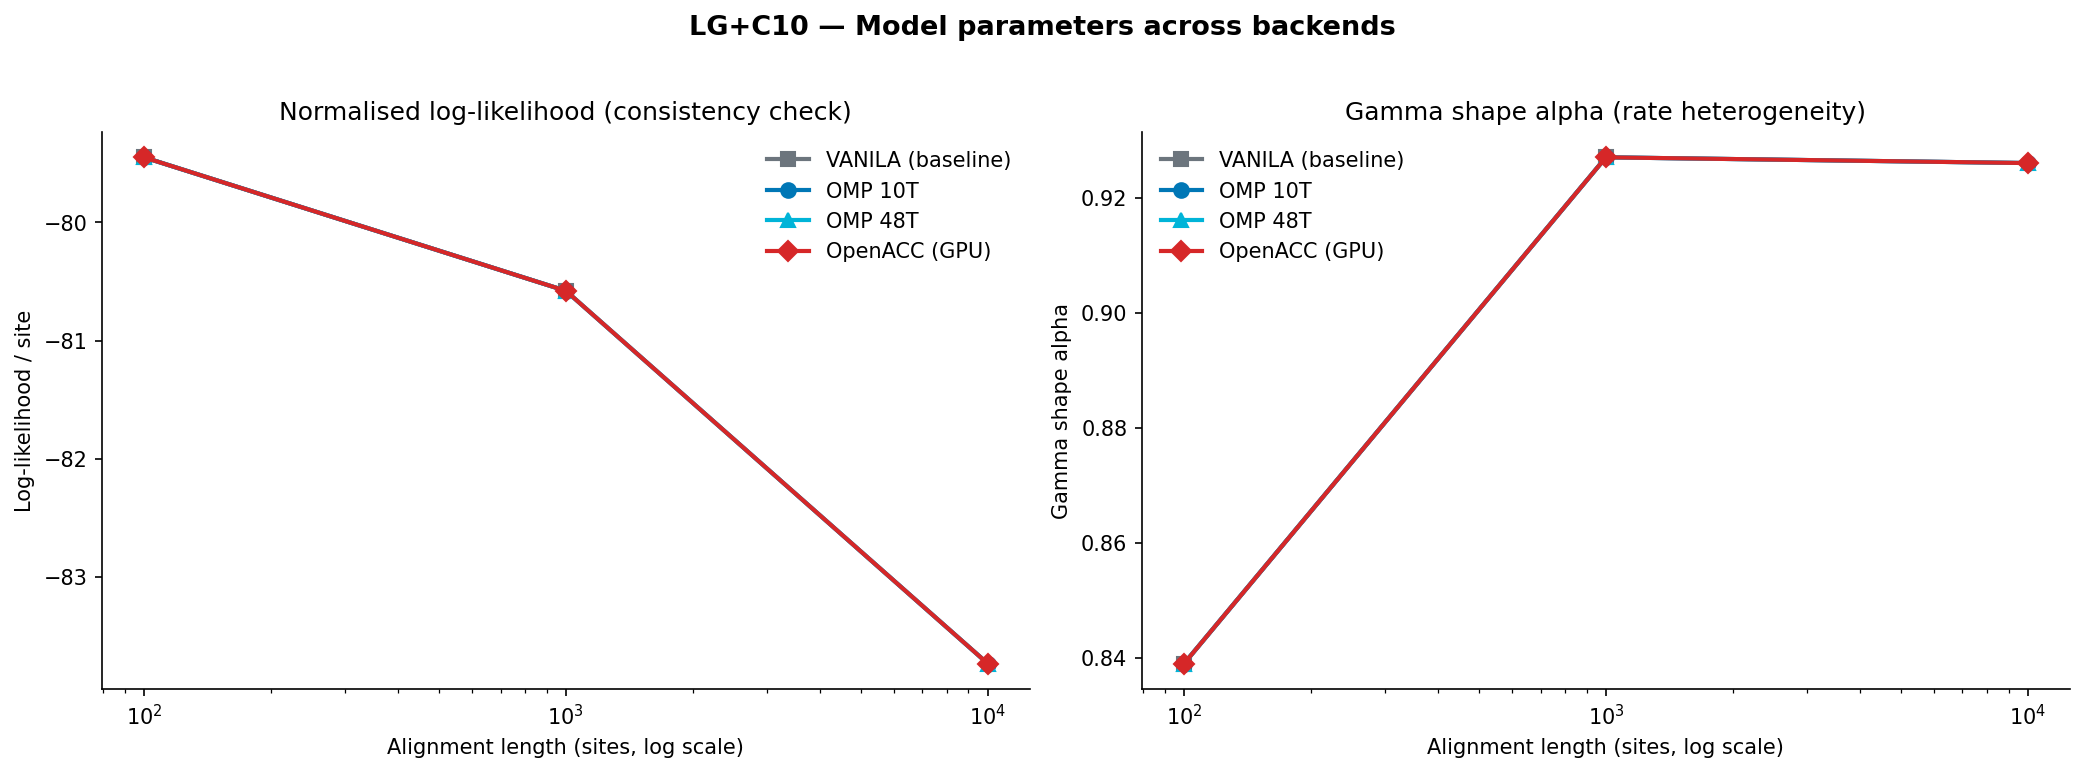

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: log-likelihood (normalised per site) ---
ax = axes[0]
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].dropna(subset=["logl"]).sort_values("seq_len")
    if sub.empty:
        continue
    norm_logl = sub["logl"] / sub["seq_len"]
    ax.plot(sub["seq_len"], norm_logl,
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=7, label=BACKEND_LABELS[b])
ax.set_xscale("log")
ax.set_xlabel("Alignment length (sites, log scale)")
ax.set_ylabel("Log-likelihood / site")
ax.set_title("Normalised log-likelihood (consistency check)")
ax.legend(frameon=False)

# --- right: gamma shape alpha ---
ax = axes[1]
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].dropna(subset=["gamma_alpha"]).sort_values("seq_len")
    if sub.empty:
        continue
    ax.plot(sub["seq_len"], sub["gamma_alpha"],
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=7, label=BACKEND_LABELS[b])
ax.set_xscale("log")
ax.set_xlabel("Alignment length (sites, log scale)")
ax.set_ylabel("Gamma shape alpha")
ax.set_title("Gamma shape alpha (rate heterogeneity)")
ax.legend(frameon=False)

plt.suptitle("LG+C10 — Model parameters across backends", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig5_model_params.png", bbox_inches="tight")
plt.show()

## Best log-likelihood comparison across backends

Since all backends run the **same model (LG+C10+G4)** on the **same alignment**, a correct implementation should find identical (or near-identical) best log-likelihoods. Any divergence reveals numerical drift between CPU and GPU kernels.

In [38]:
# Pivot table of best log-likelihoods
logl_pivot = df.pivot_table(index="backend", columns="seq_len", values="logl", aggfunc="first")
logl_pivot = logl_pivot.loc[[b for b in BACKEND_ORDER if b in logl_pivot.index]]

print("Best log-likelihood found (BEST SCORE FOUND) per backend × length:")
print(logl_pivot.round(4).to_string())

# Delta from the best (maximum, i.e., least negative) log-likelihood per length
best_per_len = logl_pivot.max(axis=0)
delta_pivot  = logl_pivot.subtract(best_per_len, axis=1)  # 0 = best, negative = worse

print("\nΔ logL from best per length (0 = winner, negative = worse fit):")
print(delta_pivot.round(4).to_string())

Best log-likelihood found (BEST SCORE FOUND) per backend × length:
seq_len     100       1000       10000
backend                               
VANILA  -7944.893 -80578.84        NaN
OMP_10  -7944.893 -80578.84 -837336.22
OMP_48  -7944.893 -80578.84 -837336.22
OPENACC -7944.893 -80578.84 -837336.22

Δ logL from best per length (0 = winner, negative = worse fit):
seq_len  100    1000   10000
backend                     
VANILA     0.0    0.0    NaN
OMP_10     0.0    0.0    0.0
OMP_48     0.0    0.0    0.0
OPENACC    0.0    0.0    0.0


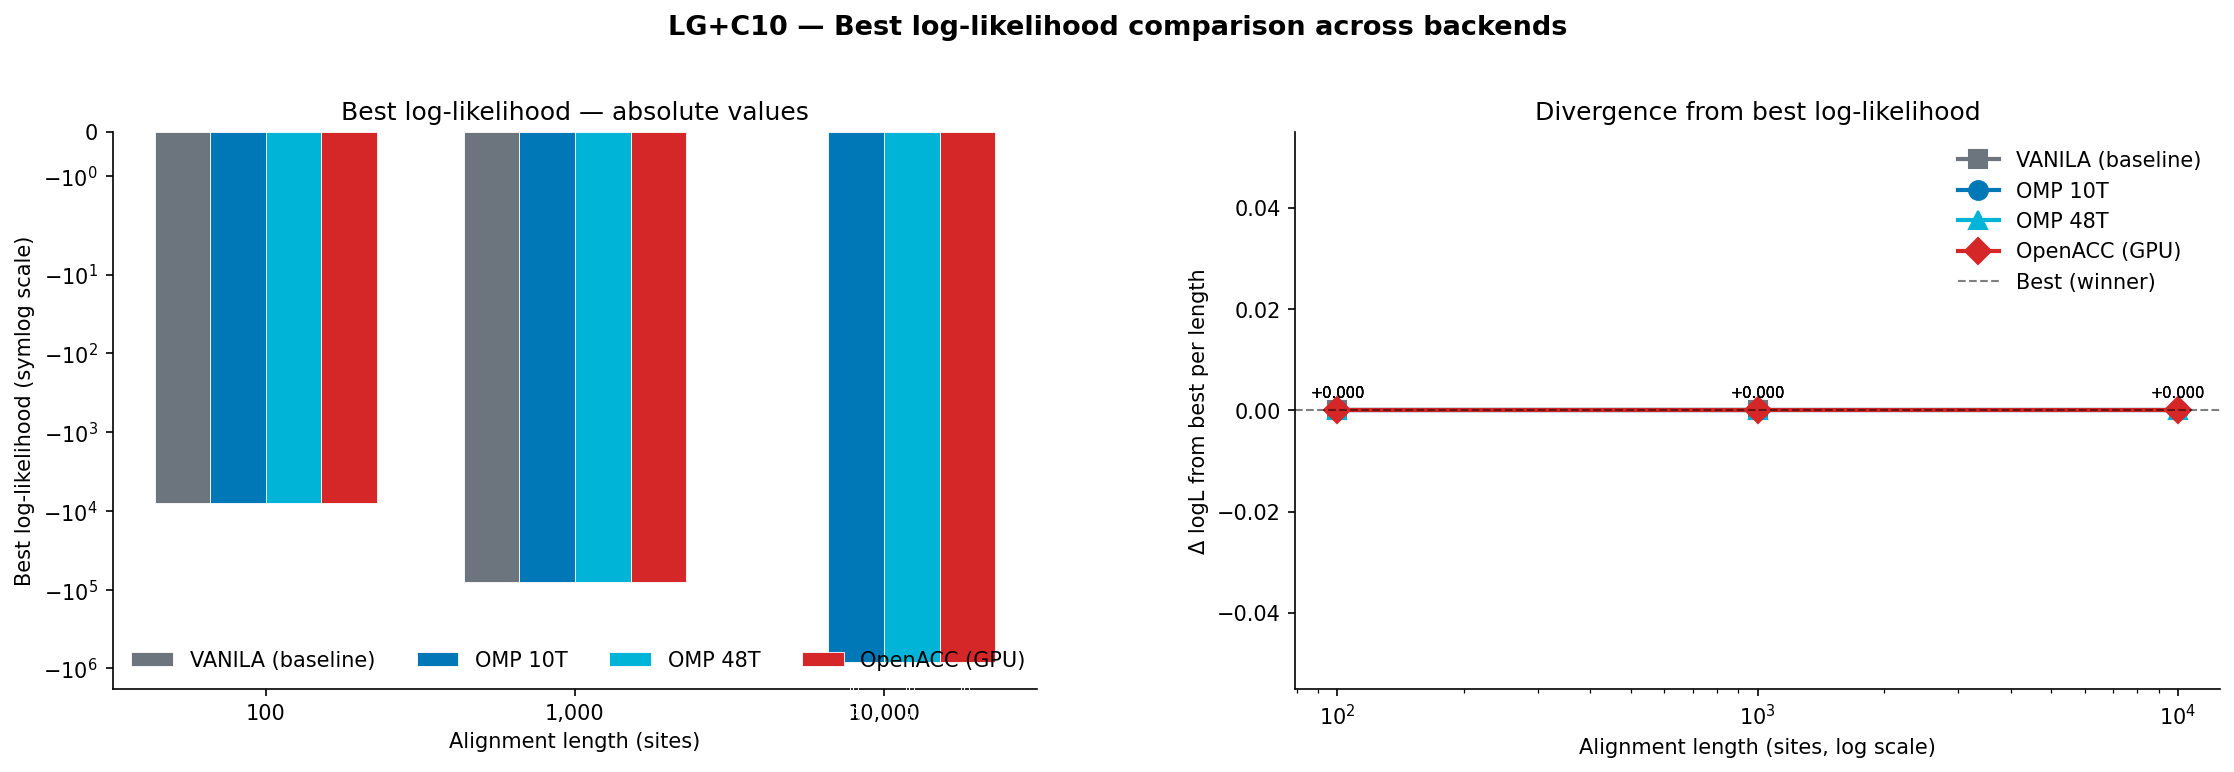

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- left: raw absolute log-likelihood per backend ---
ax = axes[0]
x = np.arange(len(logl_pivot.columns))
for i, b in enumerate(logl_pivot.index):
    offset = (i - (len(logl_pivot.index) - 1) / 2) * bar_width
    vals = logl_pivot.loc[b].values
    bars = ax.bar(x + offset, vals, bar_width,
                  label=BACKEND_LABELS[b], color=BACKEND_COLORS[b],
                  edgecolor="white", lw=0.4)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height(), f"{v:,.1f}",
                    ha="center", va="top", fontsize=6, rotation=90, color="white")
ax.set_yscale("symlog")
ax.set_xticks(x)
ax.set_xticklabels([f"{c:,}" for c in logl_pivot.columns])
ax.set_xlabel("Alignment length (sites)")
ax.set_ylabel("Best log-likelihood (symlog scale)")
ax.set_title("Best log-likelihood — absolute values")
ax.legend(frameon=False, ncol=4)

# --- right: delta from best ---
ax = axes[1]
for i, b in enumerate(delta_pivot.index):
    sub_vals = delta_pivot.loc[b].values
    ax.plot(delta_pivot.columns, sub_vals,
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            lw=2, ms=9, label=BACKEND_LABELS[b])
    for L, v in zip(delta_pivot.columns, sub_vals):
        if not np.isnan(v):
            ax.annotate(f"{v:+.3f}", xy=(L, v), xytext=(0, 6),
                        textcoords="offset points", ha="center", fontsize=7)
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.5, label="Best (winner)")
ax.set_xscale("log")
ax.set_xlabel("Alignment length (sites, log scale)")
ax.set_ylabel("Δ logL from best per length")
ax.set_title("Divergence from best log-likelihood")
ax.legend(frameon=False)

plt.suptitle("LG+C10 — Best log-likelihood comparison across backends",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig9_logl_comparison.png", bbox_inches="tight")
plt.show()

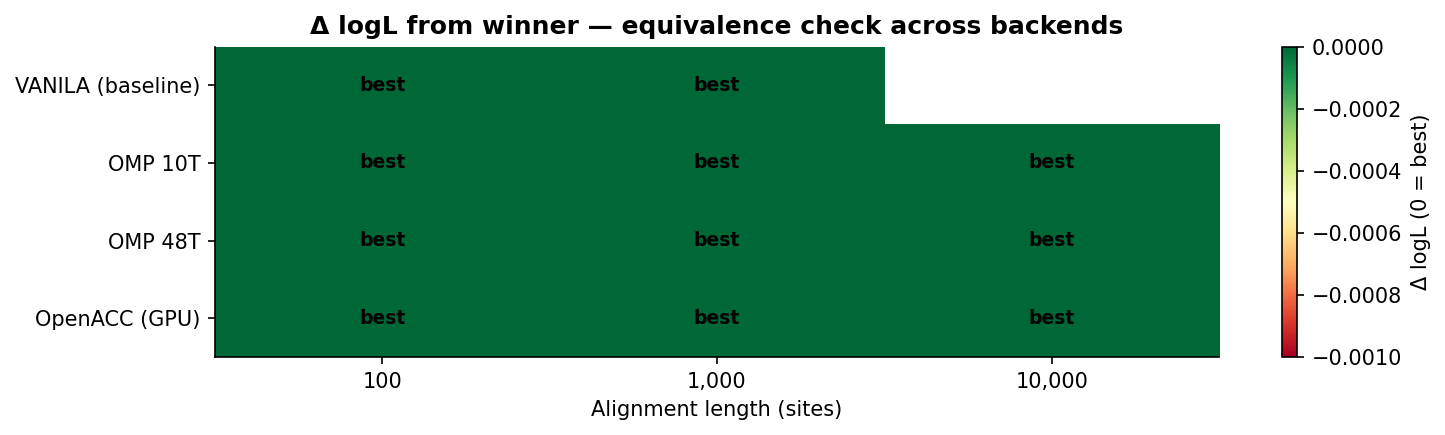


Max |Δ logL| across all backends per length:
  len=     100: spread = 0.0000  (winner: VANILA)
  len=   1,000: spread = 0.0000  (winner: VANILA)
  len=  10,000: spread = 0.0000  (winner: OMP_10)


In [40]:
# Heatmap of delta log-likelihood — quick visual for equivalence check
fig, ax = plt.subplots(figsize=(10, 3))

data = delta_pivot.values
vmax = np.nanmax(np.abs(data))
vmax = max(vmax, 1e-3)  # avoid zero range

im = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=0)
ax.set_xticks(range(len(delta_pivot.columns)))
ax.set_xticklabels([f"{c:,}" for c in delta_pivot.columns])
ax.set_yticks(range(len(delta_pivot.index)))
ax.set_yticklabels([BACKEND_LABELS[b] for b in delta_pivot.index])

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if not np.isnan(v):
            label = "best" if v == 0 else f"{v:+.3f}"
            ax.text(j, i, label, ha="center", va="center", fontsize=9,
                    color="black" if v > -vmax * 0.5 else "white",
                    fontweight="bold" if v == 0 else "normal")

ax.set_xlabel("Alignment length (sites)")
ax.set_title("Δ logL from winner — equivalence check across backends", fontweight="bold")
plt.colorbar(im, ax=ax, label="Δ logL (0 = best)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig10_logl_heatmap.png", bbox_inches="tight")
plt.show()

# Summary
print("\nMax |Δ logL| across all backends per length:")
for L in delta_pivot.columns:
    vals = delta_pivot[L].dropna()
    if len(vals) > 1:
        spread = vals.max() - vals.min()
        print(f"  len={L:>8,}: spread = {spread:.4f}  (winner: {vals.idxmax()})")

## Figure 11 — Wall-time per backend, one panel per alignment length
Styled after `2026_04_02_kernelrev/aa_final_walltime_all_backends.png`.

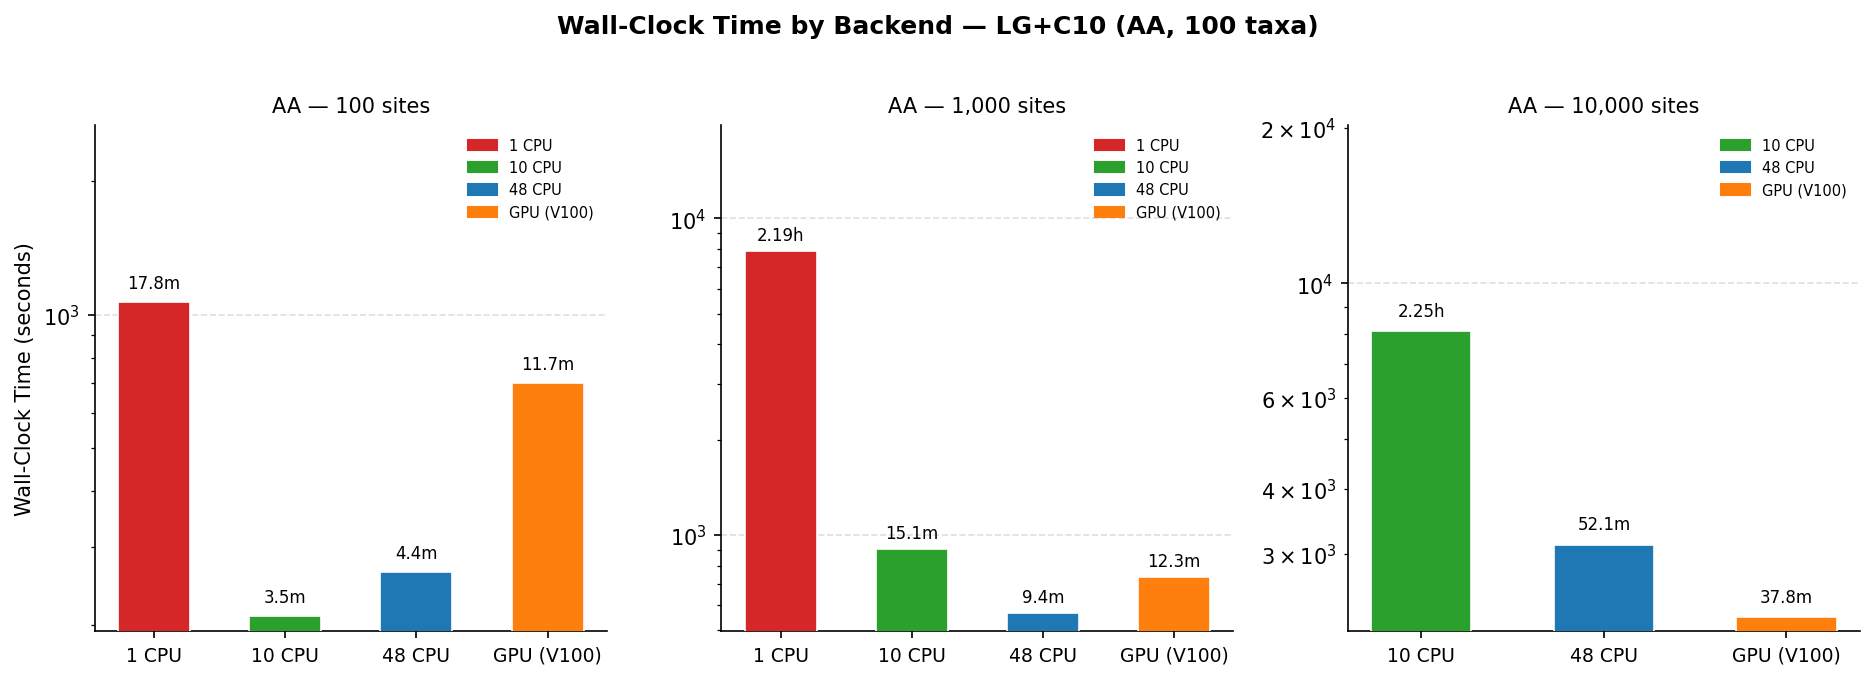

In [41]:
hw_order  = ["VANILA", "OMP_10", "OMP_48", "OPENACC"]
hw_xlabels = {"VANILA": "1 CPU", "OMP_10": "10 CPU", "OMP_48": "48 CPU", "OPENACC": "GPU (V100)"}
hw_colors  = {"VANILA": "#d62728", "OMP_10": "#2ca02c", "OMP_48": "#1f77b4", "OPENACC": "#ff7f0e"}

lengths = sorted(df["seq_len"].unique())
n = len(lengths)

fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.4), sharey=False)
if n == 1:
    axes = [axes]

for ax, L in zip(axes, lengths):
    sub = df[df["seq_len"] == L]
    present = [b for b in hw_order if b in sub["backend"].values]
    vals = [sub[sub["backend"] == b]["wall_total"].values[0] for b in present]
    colors = [hw_colors[b] for b in present]
    xpos = np.arange(len(present))

    bars = ax.bar(xpos, vals, width=0.55, color=colors,
                  edgecolor="white", lw=0.8, zorder=3)

    for bar, v in zip(bars, vals):
        if v >= 3600:
            lbl = f"{v/3600:.2f}h"
        elif v >= 60:
            lbl = f"{v/60:.1f}m"
        else:
            lbl = f"{v:.1f}s"
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.05, lbl,
                ha="center", va="bottom", fontsize=8, rotation=0)

    ax.set_yscale("log")
    ax.set_xticks(xpos)
    ax.set_xticklabels([hw_xlabels[b] for b in present], fontsize=9)
    ax.set_ylabel("Wall-Clock Time (seconds)" if ax is axes[0] else "")
    ax.set_title(f"AA — {L:,} sites", fontsize=10)
    ax.grid(axis="y", ls="--", alpha=0.4, zorder=0)
    ax.set_ylim(top=max(vals) * 2.5)

    handles = [mpatches.Patch(color=hw_colors[b], label=hw_xlabels[b]) for b in present]
    ax.legend(handles=handles, fontsize=7, frameon=False, loc="upper right")

fig.suptitle("Wall-Clock Time by Backend — LG+C10 (AA, 100 taxa)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig11_walltime_panels.png", bbox_inches="tight", dpi=180)
plt.show()

## Figure 12 — Expected runtimes for incomplete runs (power-law extrapolation)

Fit $t = a \cdot L^{b}$ in log-log space per backend using completed runs, then extrapolate to `len_100000` and `len_1000000`.

In [ ]:
def fmt_time(sec):
    if sec < 60:      return f"{sec:.1f}s"
    if sec < 3600:    return f"{sec/60:.1f}m"
    if sec < 86400:   return f"{sec/3600:.2f}h"
    return f"{sec/86400:.2f}d"

target_lengths = [100, 1000, 10000, 100000, 1000000]

rows = []
fits = {}
for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].dropna(subset=["wall_total"]).sort_values("seq_len")
    if len(sub) < 2:
        continue
    # Linear fit in log-log space: log(t) = log(a) + b*log(L)
    logL = np.log10(sub["seq_len"].values)
    logT = np.log10(sub["wall_total"].values)
    slope, intercept = np.polyfit(logL, logT, 1)
    fits[b] = (slope, intercept)

    for L in target_lengths:
        actual = sub[sub["seq_len"] == L]["wall_total"]
        actual_val = actual.values[0] if not actual.empty else None
        predicted = 10 ** (intercept + slope * np.log10(L))
        rows.append({
            "backend"  : b,
            "length"   : L,
            "slope_b"  : round(slope, 3),
            "actual"   : fmt_time(actual_val) if actual_val else "—",
            "predicted": fmt_time(predicted),
            "pred_sec" : round(predicted, 1),
            "status"   : "measured" if actual_val else "extrapolated",
        })

pred_df = pd.DataFrame(rows)
print("Expected vs measured wall-clock time (power-law fit per backend):\n")
print(pred_df.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

L_range = np.logspace(2, 6, 200)
for b in BACKEND_ORDER:
    if b not in fits:
        continue
    slope, intercept = fits[b]
    sub = df[df["backend"] == b].dropna(subset=["wall_total"]).sort_values("seq_len")

    # measured
    ax.plot(sub["seq_len"], sub["wall_total"],
            marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b],
            ms=10, lw=0, label=f"{BACKEND_LABELS[b]} measured")
    # fit line across full range
    t_fit = 10 ** (intercept + slope * np.log10(L_range))
    ax.plot(L_range, t_fit, color=BACKEND_COLORS[b], lw=1.5, ls="--", alpha=0.6,
            label=f"{BACKEND_LABELS[b]} fit  (b={slope:.2f})")

    # mark extrapolated points
    for L in target_lengths:
        actual = sub[sub["seq_len"] == L]
        if actual.empty:
            pred = 10 ** (intercept + slope * np.log10(L))
            ax.plot(L, pred, marker="x", color=BACKEND_COLORS[b], ms=14, mew=2.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Alignment length (sites)")
ax.set_ylabel("Wall-clock time (seconds)")
ax.set_title("Measured + extrapolated wall-clock time per backend\n(× markers = extrapolated)", fontweight="bold")
ax.axvspan(1e4, 1e6, alpha=0.06, color="grey", zorder=0)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
ax.grid(True, which="both", ls=":", alpha=0.3)

# secondary y-axis with human-readable time
def sec_to_human(y, _):
    return fmt_time(y)
ax2 = ax.twinx()
ax2.set_yscale("log")
ax2.set_ylim(ax.get_ylim())
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(sec_to_human))
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig(OUT_DIR / "fig12_expected_runtimes.png", bbox_inches="tight", dpi=180)
plt.show()

## Figure 6 — Mixture weight profiles across backends and lengths

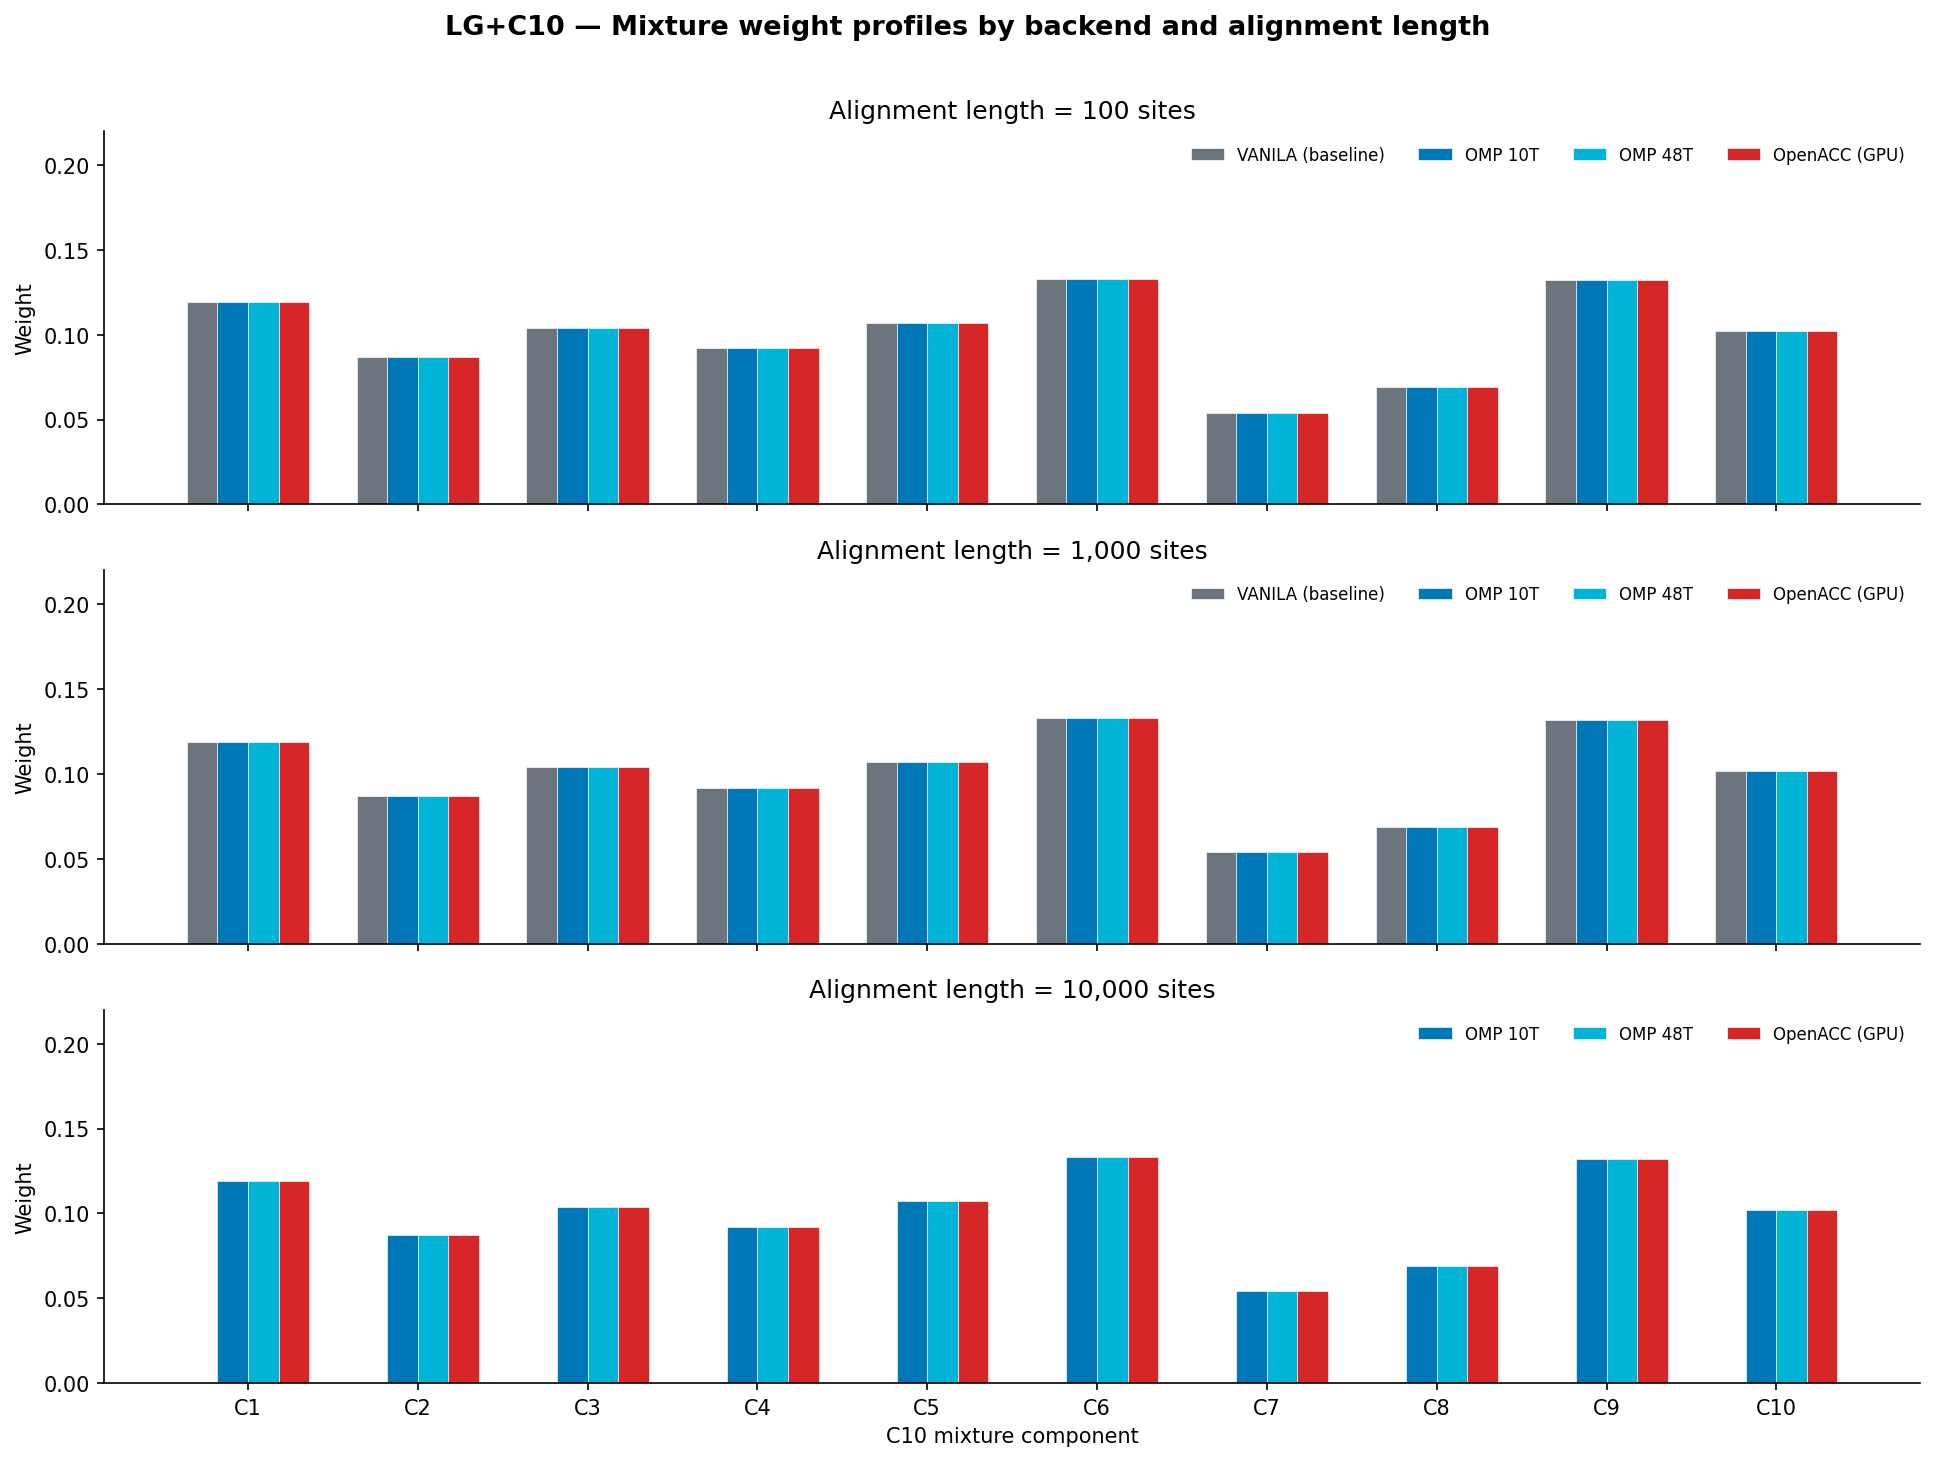

In [42]:
mw_df = df.dropna(subset=["mix_weights"]).copy()

if not mw_df.empty:
    n_comp = 10
    components = [f"C{i+1}" for i in range(n_comp)]

    unique_lengths = sorted(mw_df["seq_len"].unique())
    n_rows = len(unique_lengths)
    fig, axes = plt.subplots(n_rows, 1, figsize=(13, 3.2 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    bar_w = 0.18
    x = np.arange(n_comp)

    for ax, L in zip(axes, unique_lengths):
        sub = mw_df[mw_df["seq_len"] == L]
        for i, b in enumerate(BACKEND_ORDER):
            row = sub[sub["backend"] == b]
            if row.empty:
                continue
            weights = row["mix_weights"].values[0]
            offset = (i - (n_backends - 1) / 2) * bar_w
            ax.bar(x + offset, weights, bar_w,
                   label=BACKEND_LABELS[b], color=BACKEND_COLORS[b], edgecolor="white", lw=0.3)
        ax.set_ylabel("Weight")
        ax.set_title(f"Alignment length = {L:,} sites")
        ax.set_ylim(0, 0.22)
        ax.set_xticks(x)
        ax.set_xticklabels(components)
        ax.legend(frameon=False, fontsize=8, ncol=4)

    axes[-1].set_xlabel("C10 mixture component")
    fig.suptitle("LG+C10 — Mixture weight profiles by backend and alignment length",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig6_mixture_weights.png", bbox_inches="tight")
    plt.show()
else:
    print("No mixture weight data available.")

## Figure 7 — Heatmap: wall-clock time (minutes) across backends × lengths

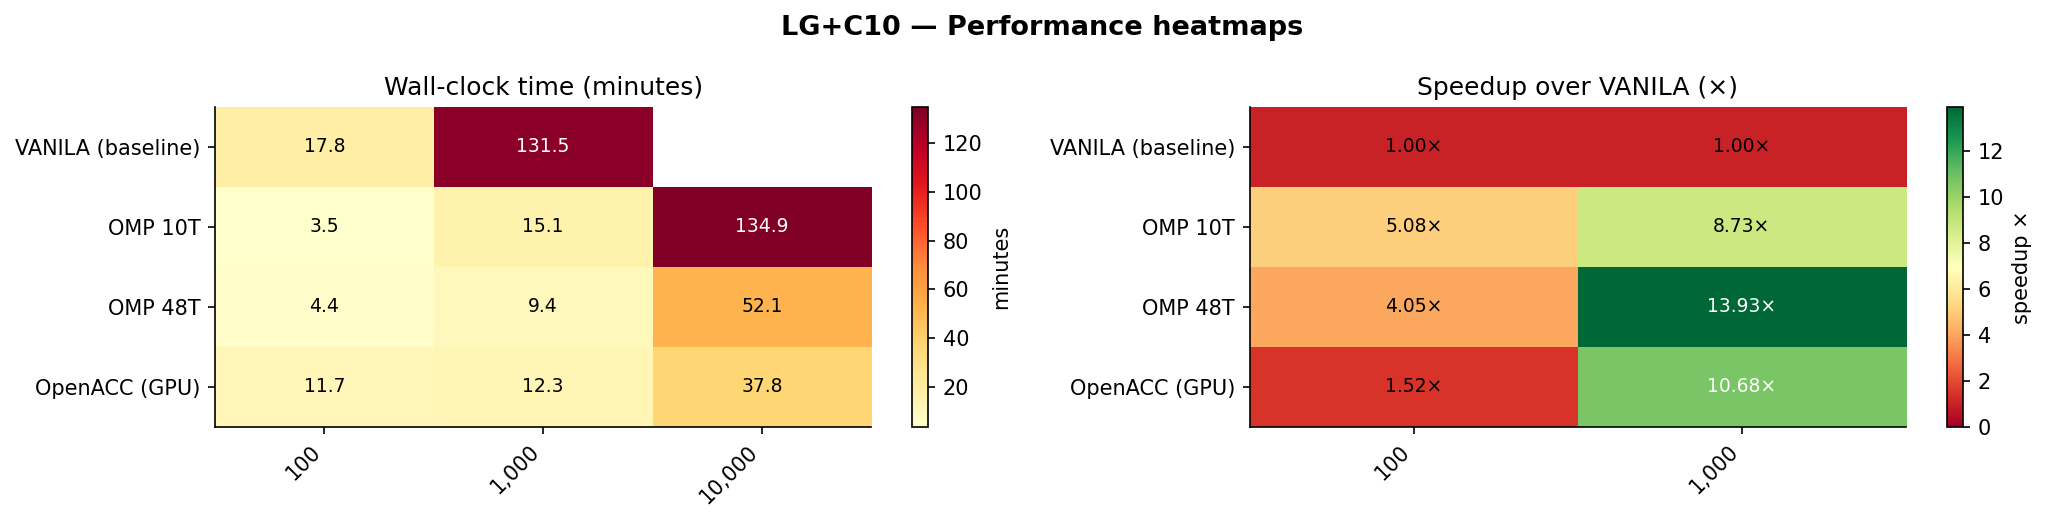

In [43]:
pivot = df.pivot_table(index="backend", columns="seq_len", values="wall_total", aggfunc="first")
pivot = pivot.loc[[b for b in BACKEND_ORDER if b in pivot.index]]
pivot_min = pivot / 60

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# --- left: raw wall-clock minutes ---
im = axes[0].imshow(pivot_min.values, aspect="auto", cmap="YlOrRd")
axes[0].set_xticks(range(len(pivot_min.columns)))
axes[0].set_xticklabels([f"{c:,}" for c in pivot_min.columns], rotation=45, ha="right")
axes[0].set_yticks(range(len(pivot_min.index)))
axes[0].set_yticklabels([BACKEND_LABELS[b] for b in pivot_min.index])
axes[0].set_title("Wall-clock time (minutes)")
for i in range(pivot_min.shape[0]):
    for j in range(pivot_min.shape[1]):
        v = pivot_min.iloc[i, j]
        if not np.isnan(v):
            txt = f"{v:.1f}" if v < 600 else f"{v/60:.1f}h"
            axes[0].text(j, i, txt, ha="center", va="center", fontsize=9,
                         color="white" if v > pivot_min.values[~np.isnan(pivot_min.values)].max() * 0.6 else "black")
plt.colorbar(im, ax=axes[0], label="minutes")

# --- right: speedup heatmap ---
pivot_su = df.pivot_table(index="backend", columns="seq_len", values="speedup", aggfunc="first")
pivot_su = pivot_su.loc[[b for b in BACKEND_ORDER if b in pivot_su.index]]
im2 = axes[1].imshow(pivot_su.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=pivot_su.values[~np.isnan(pivot_su.values)].max())
axes[1].set_xticks(range(len(pivot_su.columns)))
axes[1].set_xticklabels([f"{c:,}" for c in pivot_su.columns], rotation=45, ha="right")
axes[1].set_yticks(range(len(pivot_su.index)))
axes[1].set_yticklabels([BACKEND_LABELS[b] for b in pivot_su.index])
axes[1].set_title("Speedup over VANILA (×)")
for i in range(pivot_su.shape[0]):
    for j in range(pivot_su.shape[1]):
        v = pivot_su.iloc[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f"{v:.2f}×", ha="center", va="center", fontsize=9,
                         color="white" if v > pivot_su.values[~np.isnan(pivot_su.values)].max() * 0.7 else "black")
plt.colorbar(im2, ax=axes[1], label="speedup ×")

plt.suptitle("LG+C10 — Performance heatmaps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig7_heatmap.png", bbox_inches="tight")
plt.show()

## Figure 8 — Summary dashboard

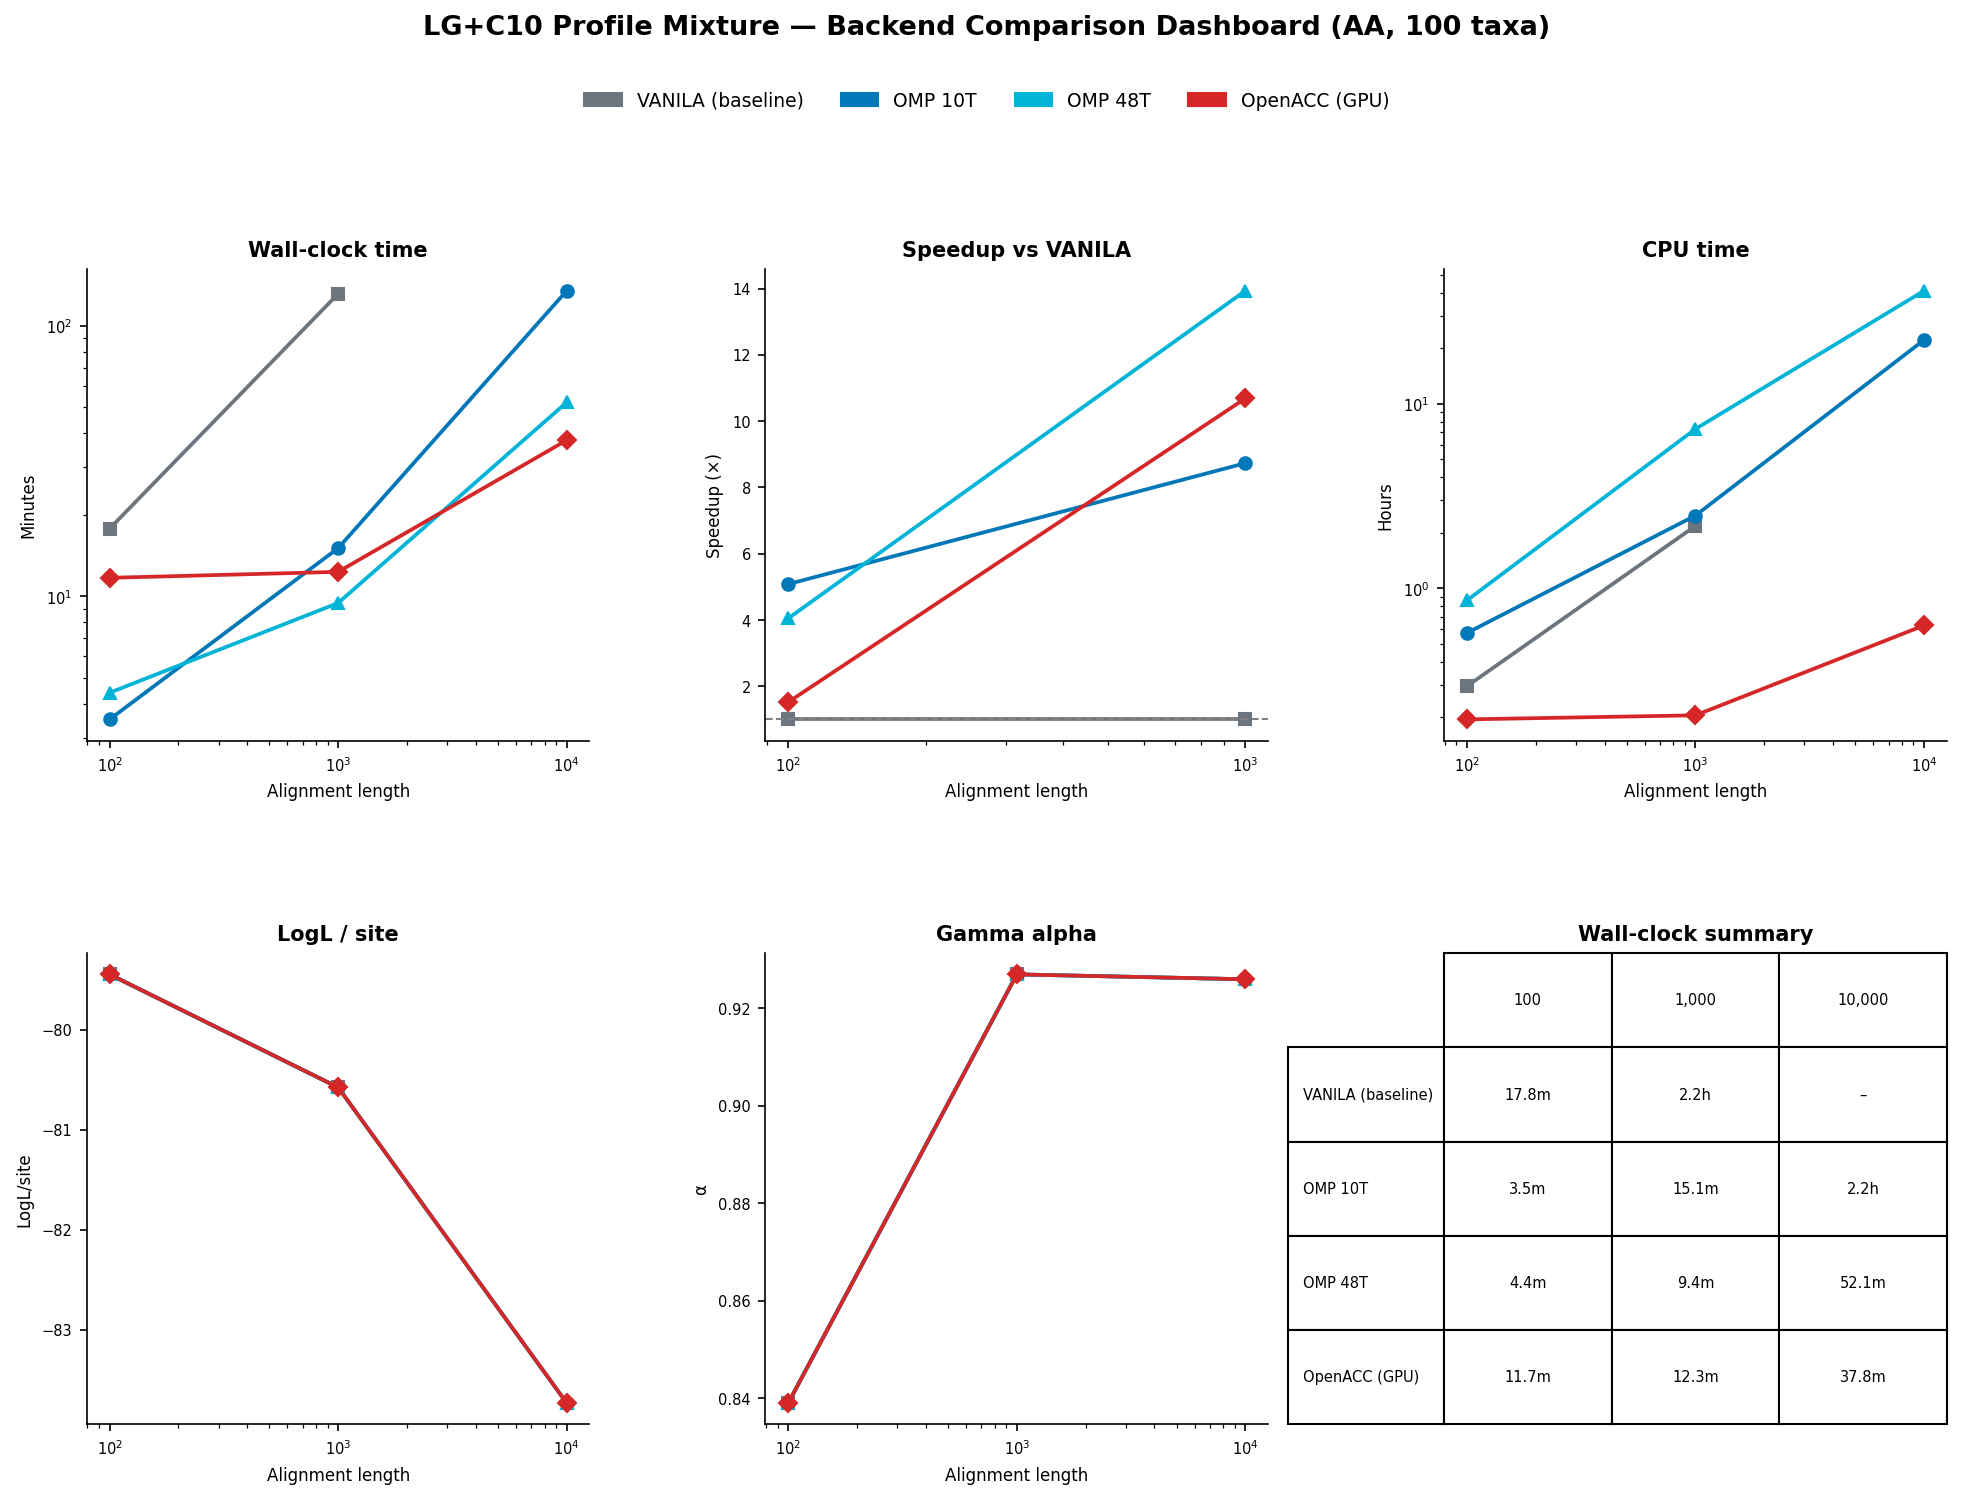

In [44]:
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax_wall  = fig.add_subplot(gs[0, 0])
ax_speed = fig.add_subplot(gs[0, 1])
ax_cpu   = fig.add_subplot(gs[0, 2])
ax_logl  = fig.add_subplot(gs[1, 0])
ax_gamma = fig.add_subplot(gs[1, 1])
ax_table = fig.add_subplot(gs[1, 2])
ax_table.axis("off")

for b in BACKEND_ORDER:
    sub = df[df["backend"] == b].sort_values("seq_len")
    if sub.empty:
        continue
    kw = dict(marker=BACKEND_MARKERS[b], color=BACKEND_COLORS[b], lw=1.8, ms=6)
    ax_wall.plot(sub["seq_len"], sub["wall_total"] / 60, label=BACKEND_LABELS[b], **kw)
    ax_speed.plot(sub["seq_len"], sub["speedup"],        label=BACKEND_LABELS[b], **kw)
    ax_cpu.plot(sub["seq_len"],  sub["cpu_total"]/3600,  label=BACKEND_LABELS[b], **kw)
    ax_logl.plot(sub["seq_len"], sub["logl"]/sub["seq_len"], label=BACKEND_LABELS[b], **kw)
    ax_gamma.plot(sub["seq_len"], sub["gamma_alpha"],    label=BACKEND_LABELS[b], **kw)

for ax, title, ylabel, yscale in [
    (ax_wall,  "Wall-clock time",     "Minutes",           "log"),
    (ax_speed, "Speedup vs VANILA",   "Speedup (×)",       "linear"),
    (ax_cpu,   "CPU time",            "Hours",             "log"),
    (ax_logl,  "LogL / site",         "LogL/site",         "linear"),
    (ax_gamma, "Gamma alpha",         "α",                 "linear"),
]:
    ax.set_xscale("log")
    ax.set_yscale(yscale)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=8)
    ax.set_xlabel("Alignment length", fontsize=8)
    ax.tick_params(labelsize=7)

ax_speed.axhline(1, color="grey", lw=1, ls="--")

# Summary table
col_labs = [f"{L:,}" for L in sorted(df["seq_len"].unique())]
row_labs  = [BACKEND_LABELS[b] for b in BACKEND_ORDER if b in df["backend"].values]
cell_text = []
for b in BACKEND_ORDER:
    if b not in df["backend"].values:
        continue
    row = []
    for L in sorted(df["seq_len"].unique()):
        val = df[(df["backend"]==b) & (df["seq_len"]==L)]["wall_total"]
        if val.empty or val.isna().all():
            row.append("–")
        else:
            v = val.values[0] / 60
            row.append(f"{v:.1f}m" if v < 60 else f"{v/60:.1f}h")
    cell_text.append(row)

tbl = ax_table.table(cellText=cell_text, rowLabels=row_labs, colLabels=col_labs,
                     cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
ax_table.set_title("Wall-clock summary", fontsize=10, fontweight="bold")

handles = [mpatches.Patch(color=BACKEND_COLORS[b], label=BACKEND_LABELS[b]) for b in BACKEND_ORDER]
fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, 1.01))

fig.suptitle("LG+C10 Profile Mixture — Backend Comparison Dashboard (AA, 100 taxa)",
             fontsize=13, fontweight="bold", y=1.05)
plt.savefig(OUT_DIR / "fig8_dashboard.png", bbox_inches="tight", dpi=180)
plt.show()

## Summary statistics table

In [45]:
summary = df[["backend","seq_len","threads","wall_total","cpu_total","speedup","parallel_eff","logl","gamma_alpha","tree_len","iterations"]].copy()
summary["wall_min"]  = (summary["wall_total"] / 60).round(2)
summary["cpu_hours"] = (summary["cpu_total"] / 3600).round(3)
summary["speedup"]   = summary["speedup"].round(3)
summary["par_eff_%"] = (summary["parallel_eff"] * 100).round(1)
summary["logl"]      = summary["logl"].round(2)
summary["gamma_alpha"]= summary["gamma_alpha"].round(4)

display_cols = ["backend","seq_len","threads","wall_min","cpu_hours","speedup","par_eff_%","logl","gamma_alpha","iterations"]
print(summary[display_cols].to_string(index=False))

backend  seq_len  threads  wall_min  cpu_hours  speedup  par_eff_%       logl  gamma_alpha  iterations
 VANILA      100        1     17.80      0.295    1.000       99.4   -7944.89        0.839         102
 OMP_10      100       10      3.50      0.573    5.082       98.2   -7944.89        0.839         102
 OMP_48      100       48      4.40      0.860    4.049       24.5   -7944.89        0.839         102
OPENACC      100        1     11.70      0.195    1.521      100.0   -7944.89        0.839         102
 VANILA     1000        1    131.49      2.179    1.000       99.4  -80578.84        0.927         102
 OMP_10     1000       10     15.06      2.480    8.731       98.8  -80578.84        0.927         102
 OMP_48     1000       48      9.44      7.304   13.931       96.7  -80578.84        0.927         102
OPENACC     1000        1     12.31      0.205   10.684      100.0  -80578.84        0.927         102
 OMP_10    10000       10    134.89     22.164      NaN       98.6 -83733